In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("glass.xlsx", sheet_name="glass")

print(df.head())
print(df.shape)

        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1
(214, 10)


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None


In [4]:
print(df.describe())

               RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000    0.290000   69.810000    0.000000   
25%      1.516522   12.907500    2.115000    1.190000   72.280000    0.122500   
50%      1.517680   13.300000    3.480000    1.360000   72.790000    0.555000   
75%      1.519157   13.825000    3.600000    1.630000   73.087500    0.610000   
max      1.533930   17.380000    4.490000    3.500000   75.410000    6.210000   

               Ca          Ba          Fe        Type  
count  214.000000  214.000000  214.000000  214.000000  
mean     8.956963    0.175047    0.057009    2.780374  
std      1.423153    0.497219    0.097439    2.103739  
min      5.430000    0.000000    0.000000    1

In [5]:
print(df.isnull().sum())

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1


In [7]:
df = df.drop_duplicates()

print(df.shape)

(213, 10)


In [8]:
print(df["Type"].value_counts().sort_index())

Type
1    69
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64


# Data Visualization

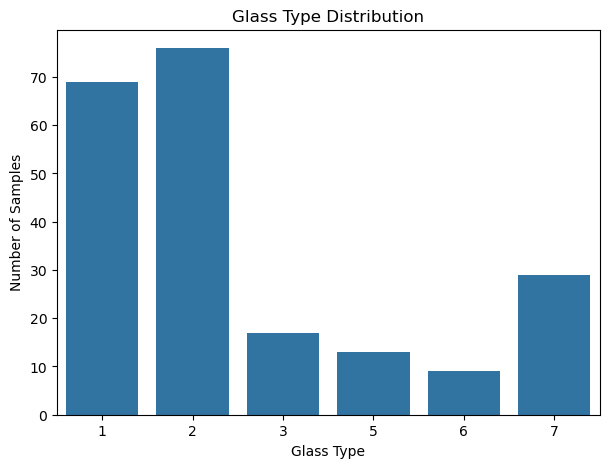

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(x="Type", data=df)

plt.title("Glass Type Distribution")
plt.xlabel("Glass Type")
plt.ylabel("Number of Samples")
plt.show()

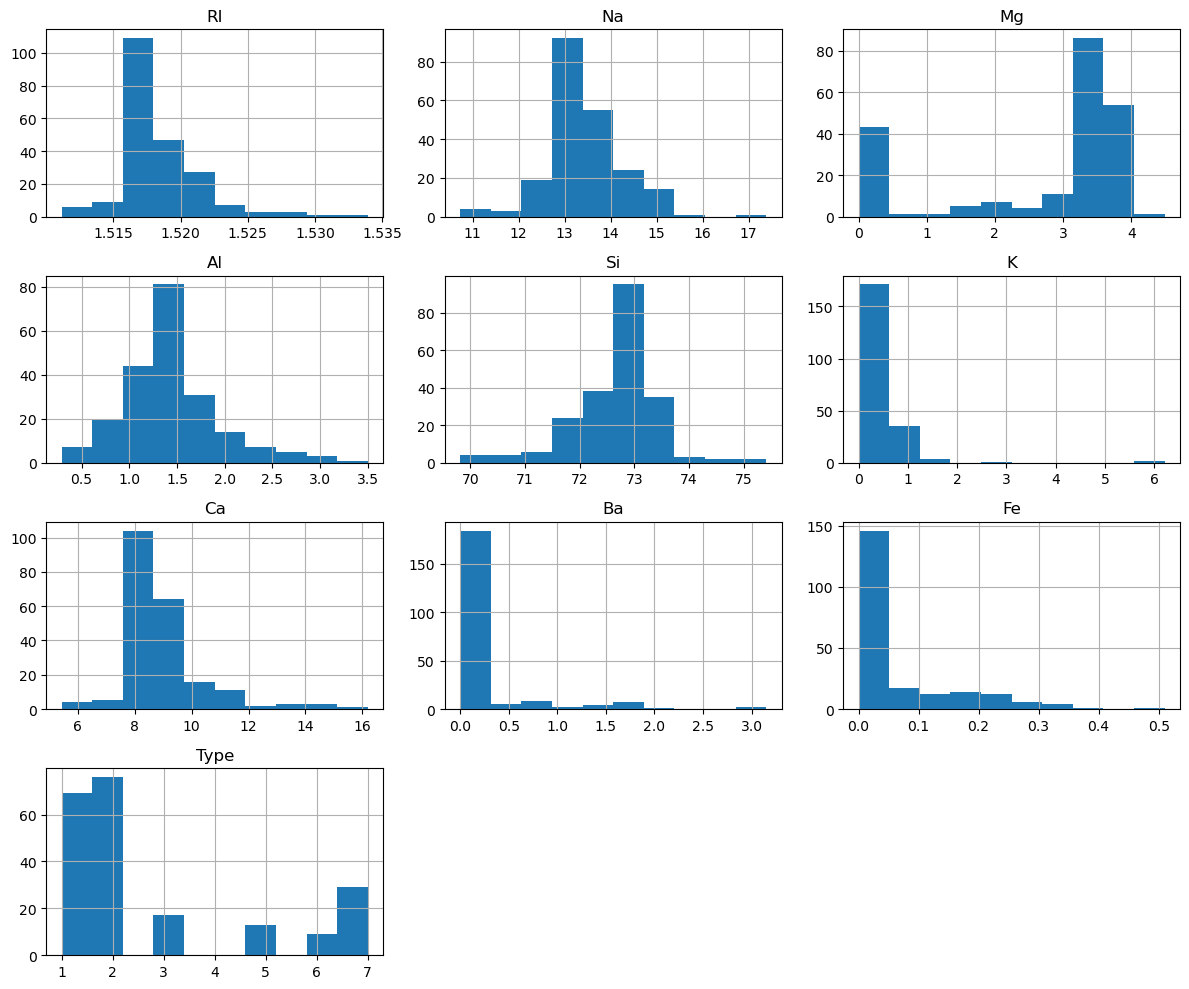

In [10]:
df.hist(figsize=(12, 10))

plt.tight_layout()
plt.show()

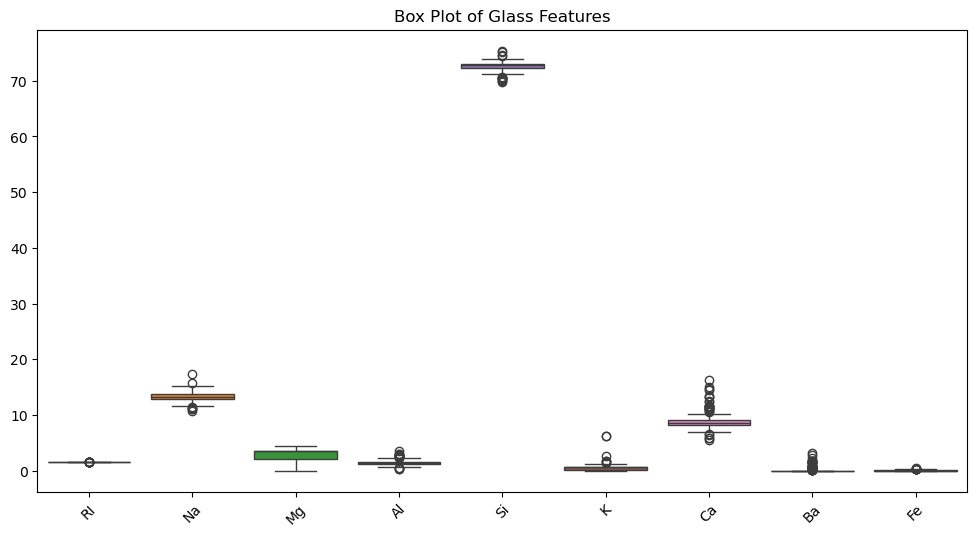

In [11]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df.drop(columns="Type"))

plt.xticks(rotation=45)
plt.title("Box Plot of Glass Features")
plt.show()

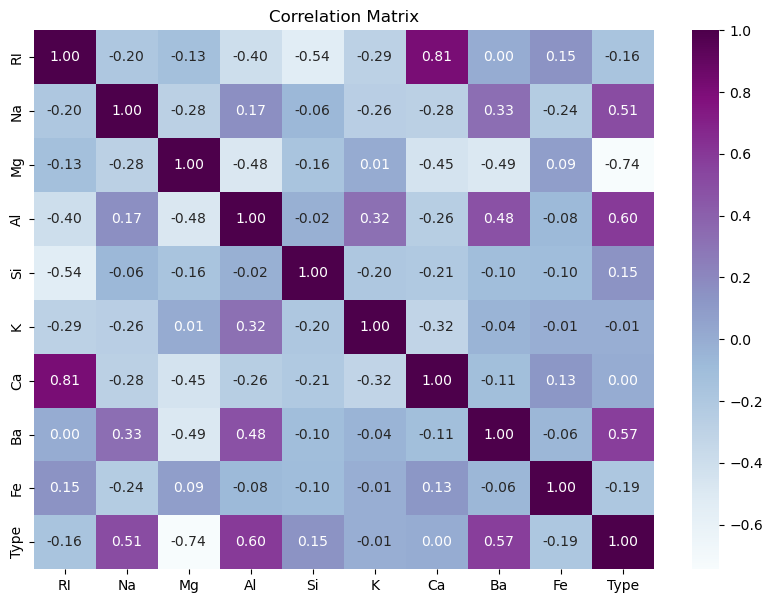

In [13]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="BuPu",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

## Data Training 

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [18]:
X = df.drop("Type", axis=1)
y = df["Type"]

In [19]:
print(X.head())

        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (170, 9)
Testing data: (43, 9)


In [21]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Random Forest Model

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier

In [23]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
y_pred = rf_model.predict(X_test)

print(y_pred)

[7 5 2 5 1 2 2 2 1 1 3 1 7 6 1 7 7 1 1 5 2 1 7 2 1 3 2 6 2 2 2 1 1 2 2 2 1
 1 2 1 1 2 6]


In [27]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

In [28]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8372093023255814


In [29]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision:", precision)

Precision: 0.8496124031007751


In [30]:
recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Recall:", recall)

Recall: 0.8372093023255814


In [31]:
f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("F1 Score:", f1)

F1 Score: 0.8381570314208645


In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.80      0.86      0.83        14
           2       0.80      0.80      0.80        15
           3       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.84        43
   macro avg       0.88      0.86      0.86        43
weighted avg       0.85      0.84      0.84        43



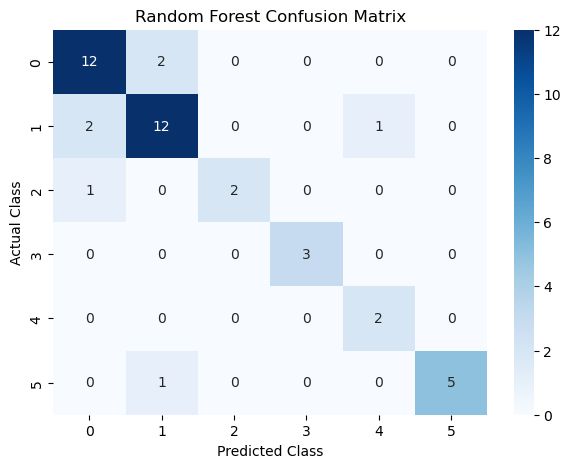

In [33]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

## Bagging Method

In [39]:
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [40]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

bagging_model.fit(X_train, y_train)

bagging_pred = bagging_model.predict(X_test)

In [41]:
bagging_accuracy = accuracy_score(y_test, bagging_pred)

bagging_precision = precision_score(
    y_test,
    bagging_pred,
    average="weighted"
)

bagging_recall = recall_score(
    y_test,
    bagging_pred,
    average="weighted"
)

bagging_f1 = f1_score(
    y_test,
    bagging_pred,
    average="weighted"
)

print("Bagging Accuracy:", bagging_accuracy)
print("Bagging Precision:", bagging_precision)
print("Bagging Recall:", bagging_recall)
print("Bagging F1 Score:", bagging_f1)

Bagging Accuracy: 0.7674418604651163
Bagging Precision: 0.7681659425845473
Bagging Recall: 0.7674418604651163
Bagging F1 Score: 0.764840517526965


## Boosting Method -AdaBoost

In [42]:
boosting_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

boosting_model.fit(X_train, y_train)

boosting_pred = boosting_model.predict(X_test)

In [43]:
boosting_accuracy = accuracy_score(
    y_test,
    boosting_pred
)

boosting_precision = precision_score(
    y_test,
    boosting_pred,
    average="weighted",
    zero_division=0
)

boosting_recall = recall_score(
    y_test,
    boosting_pred,
    average="weighted",
    zero_division=0
)

boosting_f1 = f1_score(
    y_test,
    boosting_pred,
    average="weighted",
    zero_division=0
)

print("Boosting Accuracy:", boosting_accuracy)
print("Boosting Precision:", boosting_precision)
print("Boosting Recall:", boosting_recall)
print("Boosting F1 Score:", boosting_f1)

Boosting Accuracy: 0.3953488372093023
Boosting Precision: 0.3852798364426271
Boosting Recall: 0.3953488372093023
Boosting F1 Score: 0.3857333020123717


## Comparing All the Models

In [44]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Bagging",
        "AdaBoost"
    ],

    "Accuracy": [
        accuracy,
        bagging_accuracy,
        boosting_accuracy
    ],

    "Precision": [
        precision,
        bagging_precision,
        boosting_precision
    ],

    "Recall": [
        recall,
        bagging_recall,
        boosting_recall
    ],

    "F1 Score": [
        f1,
        bagging_f1,
        boosting_f1
    ]
})

print(results)

           Model  Accuracy  Precision    Recall  F1 Score
0  Random Forest  0.837209   0.849612  0.837209  0.838157
1        Bagging  0.767442   0.768166  0.767442  0.764841
2       AdaBoost  0.395349   0.385280  0.395349  0.385733


# Model Visualization

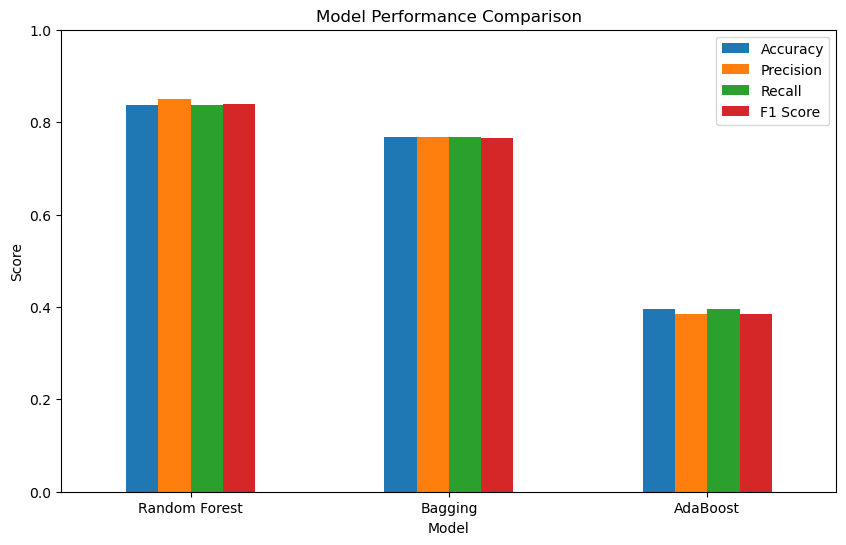

In [45]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend()

plt.show()

## Explanation of Bagging vs Boosting

Bagging

Bagging stands for Bootstrap Aggregating.

Main idea:

Take different random samples from the training dataset.
Train separate models on those samples.
Combine their predictions.
Final prediction is generally based on majority voting for classification.

Random Forest is an advanced form of bagging where multiple decision trees are trained using bootstrap samples and random subsets of features.

Boosting

Boosting builds models one after another.

The next model focuses more on observations that previous models classified incorrectly.

Examples include:

AdaBoost
Gradient Boosting
XGBoost

## 2. Explain how to handle imbalance in the data.

1. Class Weights

Give more importance to minority classes.

2. Oversampling

Increase the number of minority-class observations.
A common method is SMOTE.

3. Undersampling

Reduce the number of observations from majority classes.

4. Stratified Train-Test Split

This helps maintain class proportions in the training and testing datasets.

5. Use Appropriate Metrics

Accuracy alone can be misleading with imbalanced data.

Therefore, also consider:

Precision
Recall
F1-score
Confusion matrix
Macro F1-score